In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("tweets.csv")

df = df[['text', 'target']]
df['text'] = df['text'].fillna('')

In [3]:
X = df['text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [5]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_main_tfidf = tfidf.fit_transform(X_train_main)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [6]:
param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs']
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga']
    }
]

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_main_tfidf, y_train_main)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [7]:
y_test_probs = best_model.predict_proba(X_test_tfidf)[:, 1]

y_pred_default = (y_test_probs >= 0.5).astype(int) # dafukt threshold baseline

print("DEFAULT THRESHOLD RESULTS")
print(classification_report(y_test, y_pred_default))

DEFAULT THRESHOLD RESULTS
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1851
           1       0.74      0.54      0.62       423

    accuracy                           0.88      2274
   macro avg       0.82      0.75      0.77      2274
weighted avg       0.87      0.88      0.87      2274



In [8]:
y_val_probs = best_model.predict_proba(X_val_tfidf)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    y_pred_t = (y_val_probs >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 (Validation):", best_f1)

Best Threshold: 0.3938775510204082
Best F1 (Validation): 0.6566265060240963


In [9]:
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print("FINAL TEST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

FINAL TEST RESULTS
Accuracy: 0.8737906772207564
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1851
           1       0.68      0.62      0.65       423

    accuracy                           0.87      2274
   macro avg       0.80      0.77      0.78      2274
weighted avg       0.87      0.87      0.87      2274



In [10]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1726  125]
 [ 162  261]]


ROC-AUC: 0.8909623958936005


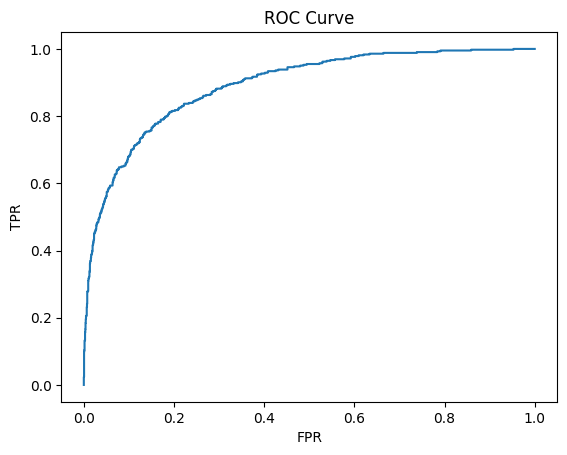

In [11]:
roc_auc = roc_auc_score(y_test, y_test_probs)
print("ROC-AUC:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_test_probs)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

PR-AUC: 0.7101982453859842


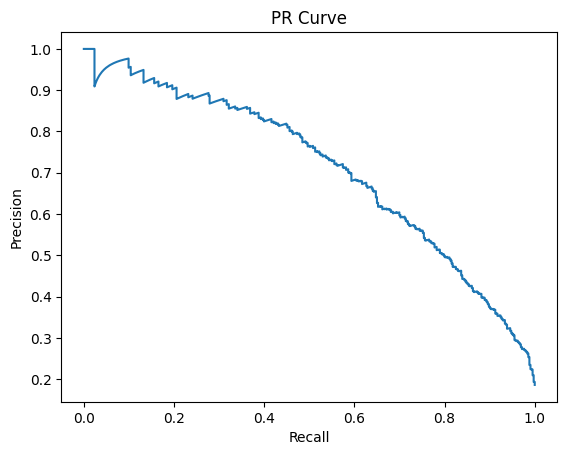

In [12]:
precision, recall, _ = precision_recall_curve(y_test, y_test_probs)
pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.show()

In [13]:
# techinque-1:: class weightage..
log_model_bal = LogisticRegression(max_iter=1000, class_weight='balanced',**grid.best_params_)

log_model_bal.fit(X_train_main_tfidf, y_train_main)

y_test_probs_bal = log_model_bal.predict_proba(X_test_tfidf)[:, 1]
y_pred_bal = (y_test_probs_bal >= best_threshold).astype(int)

print("CLASS WEIGHT RESULTS")
print(classification_report(y_test, y_pred_bal))

CLASS WEIGHT RESULTS
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      1851
           1       0.53      0.76      0.62       423

    accuracy                           0.83      2274
   macro avg       0.73      0.80      0.76      2274
weighted avg       0.86      0.83      0.84      2274



In [14]:
# techinque-2 :: smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_main_tfidf.toarray(), y_train_main)

log_model_smote = LogisticRegression(max_iter=1000,**grid.best_params_)

log_model_smote.fit(X_train_smote, y_train_smote)

y_test_probs_smote = log_model_smote.predict_proba(X_test_tfidf)[:, 1]
y_pred_smote = (y_test_probs_smote >= best_threshold).astype(int)

print("SMOTE RESULTS")
print(classification_report(y_test, y_pred_smote))

SMOTE RESULTS
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      1851
           1       0.56      0.74      0.64       423

    accuracy                           0.84      2274
   macro avg       0.75      0.80      0.77      2274
weighted avg       0.87      0.84      0.85      2274



In [15]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
rf_param_grid = {
    'n_estimators': [100, 200],          # number of trees
    'max_depth': [None, 10, 20],         # tree depth
    'min_samples_split': [2, 5],         # split condition
    'min_samples_leaf': [1, 2]           # leaf size
}

In [17]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=3,                 # keep 3 (faster)
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_main_tfidf, y_train_main)

rf_best = rf_grid.best_estimator_

print("RF Best Params:", rf_grid.best_params_)

RF Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [18]:
rf_test_probs = rf_best.predict_proba(X_test_tfidf)[:, 1]

rf_pred_default = (rf_test_probs >= 0.5).astype(int)

print("RF DEFAULT THRESHOLD")
print(classification_report(y_test, rf_pred_default))

RF DEFAULT THRESHOLD
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1851
           1       0.76      0.45      0.57       423

    accuracy                           0.87      2274
   macro avg       0.83      0.71      0.75      2274
weighted avg       0.86      0.87      0.86      2274



In [19]:
# threhsold tuning ((validation))
rf_val_probs = rf_best.predict_proba(X_val_tfidf)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)

rf_best_threshold = 0
rf_best_f1 = 0

for t in thresholds:
    y_pred_t = (rf_val_probs >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)

    if f1 > rf_best_f1:
        rf_best_f1 = f1
        rf_best_threshold = t

print("RF Best Threshold:", rf_best_threshold)
print("RF Best F1:", rf_best_f1)

RF Best Threshold: 0.36122448979591837
RF Best F1: 0.6851851851851852


In [20]:
rf_test_pred = (rf_test_probs >= rf_best_threshold).astype(int)

print("RF FINAL RESULTS")
print("Accuracy:", accuracy_score(y_test, rf_test_pred))
print(classification_report(y_test, rf_test_pred))

RF FINAL RESULTS
Accuracy: 0.8619173262972736
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      1851
           1       0.63      0.63      0.63       423

    accuracy                           0.86      2274
   macro avg       0.77      0.77      0.77      2274
weighted avg       0.86      0.86      0.86      2274



Confusion Matrix:
 [[1693  158]
 [ 156  267]]
ROC-AUC: 0.8881717504945892


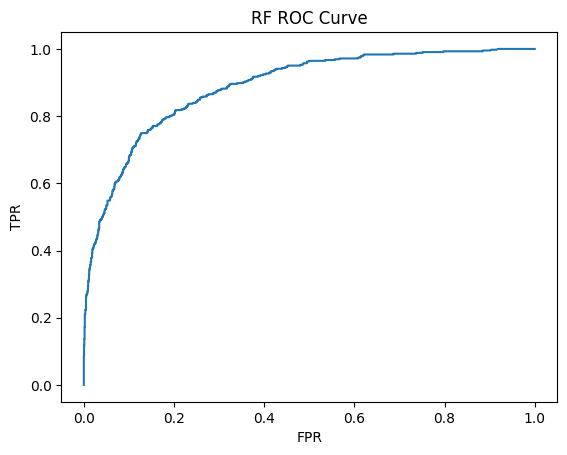

PR-AUC: 0.7100681182708131


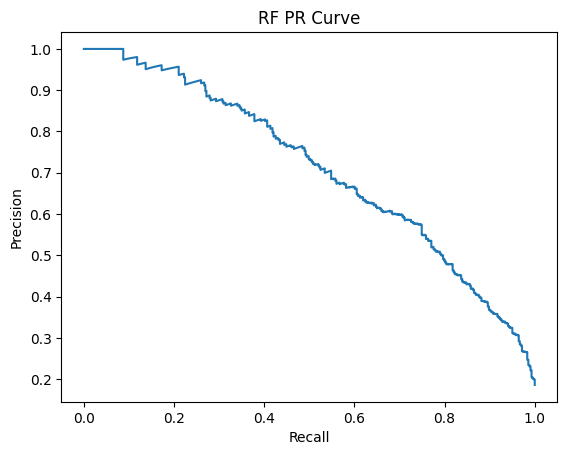

In [21]:
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_test_pred))

print("ROC-AUC:", roc_auc_score(y_test, rf_test_probs))

# precision, recall, _ = precision_recall_curve(y_test, rf_test_probs)
# pr_auc = auc(recall, precision)

# print("PR-AUC:", pr_auc)
#-------------
# ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_probs)

plt.plot(rf_fpr, rf_tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("RF ROC Curve")
plt.show()
# PR Curve
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_test_probs)
rf_pr_auc = auc(rf_recall, rf_precision)

print("PR-AUC:", rf_pr_auc)

plt.plot(rf_recall, rf_precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("RF PR Curve")
plt.show()

In [22]:
# imbalance-1 :: technique 1 :: class weight
rf_bal = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    **rf_grid.best_params_
)

rf_bal.fit(X_train_main_tfidf, y_train_main)

rf_probs_bal = rf_bal.predict_proba(X_test_tfidf)[:, 1]
rf_pred_bal = (rf_probs_bal >= rf_best_threshold).astype(int)

print("RF CLASS WEIGHT")
print(classification_report(y_test, rf_pred_bal))
print("RF Balanced ROC-AUC:", roc_auc_score(y_test, rf_probs_bal))

RF CLASS WEIGHT
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      1851
           1       0.58      0.71      0.64       423

    accuracy                           0.85      2274
   macro avg       0.76      0.80      0.77      2274
weighted avg       0.87      0.85      0.86      2274

RF Balanced ROC-AUC: 0.8907586851653888


In [23]:
X_train_smote_rf, y_train_smote_rf = smote.fit_resample(
    X_train_main_tfidf.toarray(), y_train_main
)

rf_smote = RandomForestClassifier(
    random_state=42,
    **rf_grid.best_params_
)

rf_smote.fit(X_train_smote_rf, y_train_smote_rf)

rf_probs_smote = rf_smote.predict_proba(X_test_tfidf)[:, 1]
rf_pred_smote = (rf_probs_smote >= rf_best_threshold).astype(int)

print("RF SMOTE")
print(classification_report(y_test, rf_pred_smote))

print("RF SMOTE ROC-AUC:", roc_auc_score(y_test, rf_probs_smote))

RF SMOTE
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      1851
           1       0.60      0.68      0.64       423

    accuracy                           0.85      2274
   macro avg       0.76      0.79      0.77      2274
weighted avg       0.86      0.85      0.86      2274

RF SMOTE ROC-AUC: 0.8891839182194022


In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.regularizers import l2

In [25]:
X_train_nn = X_train_main_tfidf.toarray()
X_val_nn = X_val_tfidf.toarray()
X_test_nn = X_test_tfidf.toarray()

In [26]:
def create_model(activation='relu',
                 optimizer_name='adam',
                 learning_rate=0.001,
                 dropout_rate=0.3,
                 l2_reg=0.001,
                 init='he_uniform'):

    model = Sequential()

    # NOTE:
    # Dropout layers are regularization layers (NOT additional hidden layers)

    # Hidden Layer 1 (64 neurons)
    model.add(Dense(64,
                    input_dim=X_train_nn.shape[1],
                    kernel_initializer=init,
                    kernel_regularizer=l2(l2_reg)))

    if activation == 'leakyrelu':
        model.add(LeakyReLU())
    else:
        model.add(tf.keras.layers.Activation(activation))

    model.add(Dropout(dropout_rate))

    # Hidden Layer 2 (32 neurons)
    model.add(Dense(32, activation=activation))
    model.add(Dropout(dropout_rate))

    # Hidden Layer 3 (16 neurons)
    model.add(Dense(16, activation=activation))

    # Output
    model.add(Dense(1, activation='sigmoid'))

    # Optimizer
    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    else:
        optimizer = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [27]:
configs = [
    {'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'init': 'he_uniform'},
    {'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'init': 'glorot_uniform'},
    {'activation': 'tanh', 'optimizer': 'adam', 'lr': 0.001, 'init': 'glorot_uniform'},
    {'activation': 'relu', 'optimizer': 'sgd', 'lr': 0.01, 'init': 'he_uniform'}
]

In [28]:
results = []

for config in configs:
    print("\nRunning:", config)

    model = create_model(
        activation=config['activation'],
        optimizer_name=config['optimizer'],
        learning_rate=config['lr'],
        dropout_rate=0.3,
        l2_reg=0.001,
        init=config['init']   # ✅ FIXED
    )

    model.fit(
        X_train_nn, y_train_main,
        validation_data=(X_val_nn, y_val),
        epochs=5,
        batch_size=32,
        verbose=0
    )

    y_val_probs = model.predict(X_val_nn).flatten()

    best_f1 = 0
    best_t = 0

    for t in np.linspace(0.1, 0.9, 20):
        y_pred = (y_val_probs >= t).astype(int)
        f1 = f1_score(y_val, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    results.append((config, best_f1, best_t))

    print("F1:", best_f1, "Threshold:", best_t)


Running: {'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'init': 'he_uniform'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
F1: 0.6339869281045751 Threshold: 0.6894736842105262

Running: {'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'init': 'glorot_uniform'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
F1: 0.6432748538011696 Threshold: 0.3526315789473684

Running: {'activation': 'tanh', 'optimizer': 'adam', 'lr': 0.001, 'init': 'glorot_uniform'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
F1: 0.6435331230283912 Threshold: 0.5210526315789473

Running: {'activation': 'relu', 'optimizer': 'sgd', 'lr': 0.01, 'init': 'he_uniform'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
F1: 0.3132530120481928 Threshold: 0.1


In [29]:
best_config = max(results, key=lambda x: x[1])
print("\nBEST CONFIG:", best_config)

best_params = best_config[0]
best_threshold_nn = best_config[2]


BEST CONFIG: ({'activation': 'tanh', 'optimizer': 'adam', 'lr': 0.001, 'init': 'glorot_uniform'}, 0.6435331230283912, np.float64(0.5210526315789473))


In [30]:
model = create_model(
    activation=best_params['activation'],
    optimizer_name=best_params['optimizer'],
    learning_rate=best_params['lr'],
    dropout_rate=0.3,
    l2_reg=0.001,
    init=best_params['init']   # ✅ FIXED
)

model.fit(
    X_train_nn, y_train_main,
    validation_data=(X_val_nn, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8496 - loss: 0.4237 - val_accuracy: 0.8692 - val_loss: 0.3769
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9125 - loss: 0.2982 - val_accuracy: 0.8714 - val_loss: 0.4005
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9304 - loss: 0.2607 - val_accuracy: 0.8538 - val_loss: 0.4233
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9432 - loss: 0.2379 - val_accuracy: 0.8604 - val_loss: 0.4526
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9486 - loss: 0.2252 - val_accuracy: 0.8659 - val_loss: 0.4716
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9546 - loss: 0.2119 - val_accuracy: 0.8593 - val_loss: 0.5346
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9579 - loss: 0.2030 - val_accuracy: 0.8615 - val_loss: 0.5397
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9598 - loss: 0.1994 - val_accuracy: 0

In [31]:
y_test_probs_nn = model.predict(X_test_nn).flatten()
y_test_pred_nn = (y_test_probs_nn >= best_threshold_nn).astype(int)

print("MLP FINAL RESULTS")
print("Accuracy:", accuracy_score(y_test, y_test_pred_nn))
print(classification_report(y_test, y_test_pred_nn))

print("ROC-AUC:", roc_auc_score(y_test, y_test_probs_nn))

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
MLP FINAL RESULTS
Accuracy: 0.855321020228672
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1851
           1       0.62      0.58      0.60       423

    accuracy                           0.86      2274
   macro avg       0.76      0.75      0.76      2274
weighted avg       0.85      0.86      0.85      2274

ROC-AUC: 0.8552932221162161


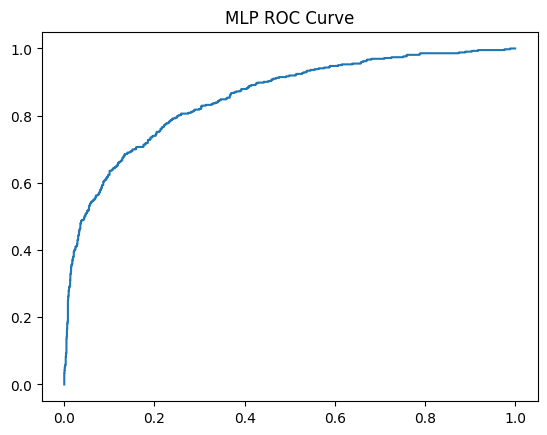

PR-AUC: 0.6506207793221583


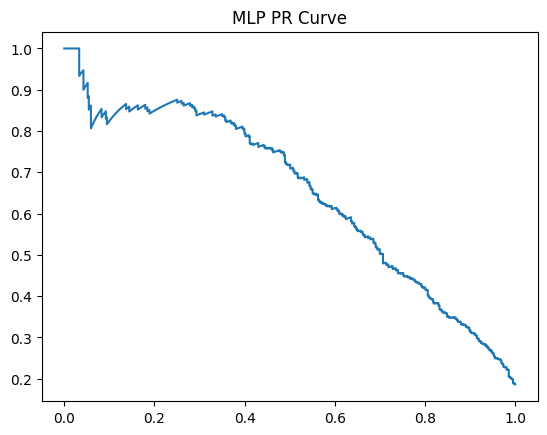

In [32]:
fpr, tpr, _ = roc_curve(y_test, y_test_probs_nn)
plt.plot(fpr, tpr)
plt.title("MLP ROC Curve")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_test_probs_nn)
pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.plot(recall, precision)
plt.title("MLP PR Curve")
plt.show()

In [33]:
model_bal = create_model(
    activation=best_params['activation'],
    optimizer_name=best_params['optimizer'],
    learning_rate=best_params['lr'],
    dropout_rate=0.3,
    l2_reg=0.001,
    init=best_params['init']
)

model_bal.fit(
    X_train_nn, y_train_main,
    epochs=10,
    batch_size=32,
    class_weight={0:1, 1:3},
    verbose=1
)

y_probs_bal = model_bal.predict(X_test_nn).flatten()
y_pred_bal = (y_probs_bal >= best_threshold_nn).astype(int)

print("MLP CLASS WEIGHT")
print(classification_report(y_test, y_pred_bal))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8341 - loss: 0.7684
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8943 - loss: 0.5098
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9260 - loss: 0.4162
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9423 - loss: 0.3609
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9510 - loss: 0.3328
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9559 - loss: 0.3177
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9563 - loss: 0.3099
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9638 - loss: 0.2829
Epoch 9/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9596 - loss: 0.3019
Epoch 10/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9668 - loss: 0.2744
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MLP CLASS WEIGHT
              precision    recall  f1-score   support

           0       0.92     

In [34]:
# SMOTE applied only on training data
X_train_smote_nn, y_train_smote_nn = smote.fit_resample(
    X_train_nn, y_train_main
)

model_smote = create_model(
    activation=best_params['activation'],
    optimizer_name=best_params['optimizer'],
    learning_rate=best_params['lr'],
    dropout_rate=0.3,
    l2_reg=0.001,
    init=best_params['init']
)

model_smote.fit(
    X_train_smote_nn, y_train_smote_nn,
    epochs=10,
    batch_size=32,
    verbose=1
)

y_probs_smote = model_smote.predict(X_test_nn).flatten()
y_pred_smote = (y_probs_smote >= best_threshold_nn).astype(int)

print("MLP SMOTE")
print(classification_report(y_test, y_pred_smote))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8741 - loss: 0.3598
Epoch 2/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9505 - loss: 0.2233
Epoch 3/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9605 - loss: 0.2008
Epoch 4/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9667 - loss: 0.1918
Epoch 5/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9693 - loss: 0.1862
Epoch 6/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9698 - loss: 0.1812
Epoch 7/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9742 - loss: 0.1724
Epoch 8/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9726 - loss: 0.1696
Epoch 9/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9755 - loss: 0.1607
Epoch 10/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9749 - loss: 0.1560
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MLP SMOTE
              precision    recall  f1-score   support

           0       0.91      0.91  